In [10]:
import sys

# Install dependencies if the notebook is running in Colab
if 'google.colab' in sys.modules:
    !pip install -U -qq reservoir_computing tsa_course

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.integrate import solve_ivp
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.utils import make_forecasting_dataset
from tsa_course.lecture11 import computeLE, plot_bifurcation_diagram
np.random.seed(0)

---
## Exercises

### Упражнение 1

- Вычислить карту бифуркации системы Ресслера.
- Оставьте фиксированными параметры $a = b = 0.2$.
- Измените параметр $c$, как показано ниже.
- Для каждого значения $c$ вычислите и постройте локальные максимумы временного ряда $z(t)$, используя функцию `scipy.signal.find_peaks`. У вас должен получиться график, похожий на рисунок ниже.
- Определите первую точку бифуркации, прежде чем система станет хаотичной.
- Объясните, почему для логистической карты не требовалось вычисление локальных максимумов (пиков).
plot_attractor(states_tr_pca.T, title="Траектория состояний резервуара", interactive=False)
<img src="https://github.com/fmi-ml-courses/ts-magi-2025-2026/blob/main/data/l11/rossler_attractor.png?raw=1" style="width: 100%; display: block; margin: auto;">

In [17]:
c_values = np.linspace(2, 15, 300) # value of c to explore

In [ ]:
from scipy.signal import find_peaks
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import pandas as pd

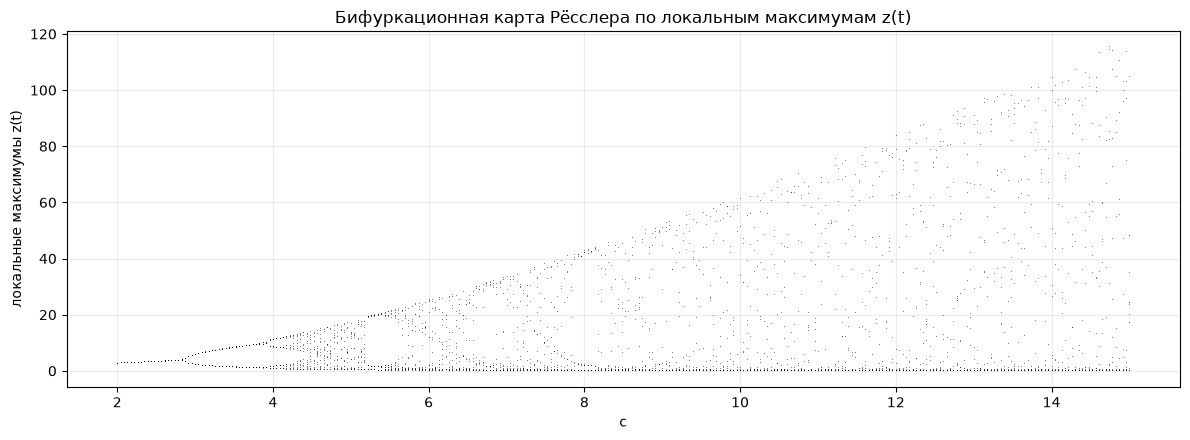

Оценка первой бифуркации (period-1 -> period-2): c ~= 2.565


In [19]:
# Define the Rössler attractor system of equations
def rossler_system(t, y, a, b, c):
    x, y, z = y
    dxdt = -y - z
    dydt = x + a*y
    dzdt = b + z*(x - c)
    return [dxdt, dydt, dzdt]

# Бифуркационная карта Рёсслера по локальным максимумам z(t)
a = b = 0.2

c_scan = np.asarray(c_values, dtype=float)

dt = 0.10
T = 220.0
t_eval = np.arange(0.0, T + dt, dt)
transient = int(0.60 * len(t_eval))

initial_state = np.array([0.0, 2.0, 0.0], dtype=float)
peak_sets = []
peak_level_count = []


def count_peak_levels(peaks):
    if len(peaks) == 0:
        return 0
    sorted_peaks = np.sort(np.asarray(peaks, dtype=float))
    eps = max(0.03, 0.08 * np.std(sorted_peaks))
    levels = 1
    level_ref = sorted_peaks[0]
    for value in sorted_peaks[1:]:
        if abs(value - level_ref) > eps:
            levels += 1
            level_ref = value
    return levels


for c in c_scan:
    sol = solve_ivp(
        rossler_system,
        (0.0, T),
        initial_state,
        args=(a, b, float(c)),
        t_eval=t_eval,
        rtol=1e-6,
        atol=1e-9,
    )

    z_ss = sol.y[2, transient:]
    peaks_idx, _ = find_peaks(z_ss, distance=max(1, int(2.0 / dt)))
    z_peaks = z_ss[peaks_idx]

    # Оцениваем асимптотический режим по хвосту максимумов.
    tail_peaks = z_peaks[-50:] if z_peaks.size > 50 else z_peaks
    peak_sets.append(tail_peaks)
    peak_level_count.append(count_peak_levels(tail_peaks))

    # Теплый старт для следующего значения c.
    initial_state = sol.y[:, -1]

plt.figure(figsize=(12, 4.5))
for c, z_peaks in zip(c_scan, peak_sets):
    if z_peaks.size == 0:
        continue
    plt.plot(np.full_like(z_peaks, c, dtype=float), z_peaks, ",k", alpha=0.5)
plt.title("Бифуркационная карта Рёсслера по локальным максимумам z(t)")
plt.xlabel("c")
plt.ylabel("локальные максимумы z(t)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Первая бифуркация: устойчивый переход от 1 уровня к >=2.
first_bifurcation = None
for i in range(len(c_scan) - 7):
    if peak_level_count[i] == 1 and np.sum(np.array(peak_level_count[i + 1 : i + 8]) >= 2) >= 5:
        first_bifurcation = float(c_scan[i + 1])
        break
if first_bifurcation is None:
    for c, n_levels in zip(c_scan, peak_level_count):
        if n_levels >= 2:
            first_bifurcation = float(c)
            break

print(f"Оценка первой бифуркации (period-1 -> period-2): c ~= {first_bifurcation:.3f}")


Логистическая карта уже дискретна по времени, а для непрерывной системы Рёсслера локальные максимумы играют роль сечения Пуанкаре.

### Упражнение 2

- Вычислите (фрактальную) размерность объекта, показанного на рисунке ниже.

<img src="https://github.com/fmi-ml-courses/ts-magi-2025-2026/blob/main/data/l11/menger-sr.jpeg?raw=1" style="width: 40%; display: block; margin: auto;">

In [20]:
# Фрактальная размерность губки Менгера
menger_dimension = np.log(20.0) / np.log(3.0)
print(f"Фрактальная размерность D = log(20)/log(3) = {menger_dimension:.6f}")


Фрактальная размерность D = log(20)/log(3) = 2.726833


### Упражнение 3

- Постройте аттрактор Лоренца для $\sigma = 10$, $\rho = 28$ и $\beta = \frac{8}{3}$.

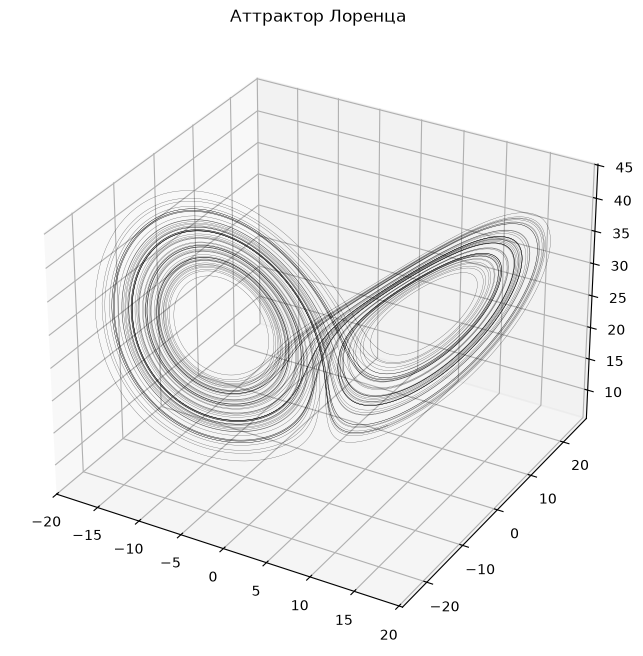

In [21]:
def plot_attractor(data, title="", interactive=False):
    xt, yt, zt = data[0], data[1], data[2]
    if interactive:
        fig = go.Figure(data=[go.Scatter3d(x=xt, y=yt, z=zt, mode='lines', line=dict(color='black', width=1))])
        fig.update_layout(title=title, scene=dict(xaxis_title='x(t)', yaxis_title='y(t)', zaxis_title='z(t)'),
                          autosize=False, width=800, height=600, margin=dict(l=0, r=0, b=0, t=0))
        fig.show()
    else:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(xt, yt, zt, linewidth=0.2, alpha=0.7, color='k')
        ax.set_title(title)
        plt.show()

def lorenz(t, x, sigma, rho, beta):
    res = np.zeros_like(x)
    res[0] = sigma*(x[1] - x[0])
    res[1] = x[0]*(rho - x[2]) - x[1]
    res[2] = x[0]*x[1] - beta*x[2]
    return res

# Аттрактор Лоренца при sigma=10, rho=28, beta=8/3
sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0

t_lor = np.linspace(0.0, 80.0, 20000)
x0_lor = np.array([1.5, -1.5, 20.0], dtype=float)

lor_sol = solve_ivp(
    lorenz,
    (t_lor[0], t_lor[-1]),
    x0_lor,
    args=(sigma, rho, beta),
    t_eval=t_lor,
    rtol=1e-8,
    atol=1e-10,
)

lor_traj = lor_sol.y.T
x_ts = lor_traj[:, 0]

plot_attractor(lor_sol.y, title="Аттрактор Лоренца", interactive=False)


### Упражнение 4

- Используйте вложение Taken, чтобы восстановить аттрактор Лоренца по временному ряду его первой переменной состояния $x(t)$.
- Вычислите оптимальную временную задержку $\tau$ и оптимальную размерность вложения $m$, используя алгоритмы взаимной информации и ложных ближайших соседей.

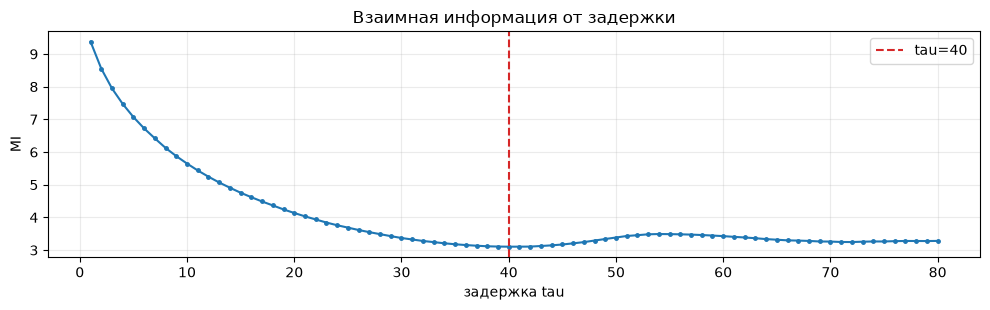

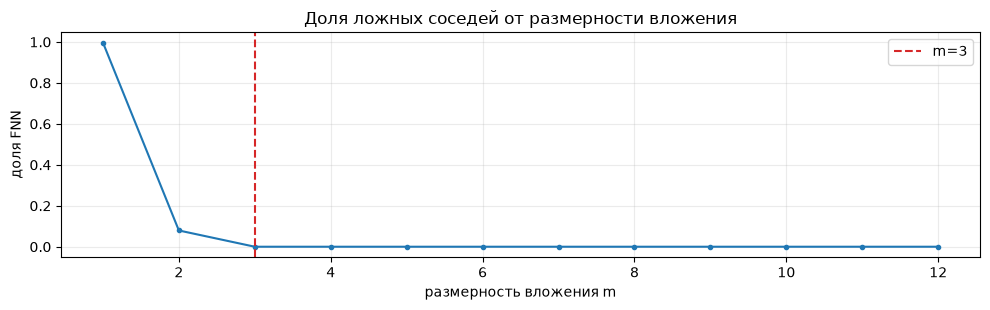

Выбраны параметры: tau=40, m=3


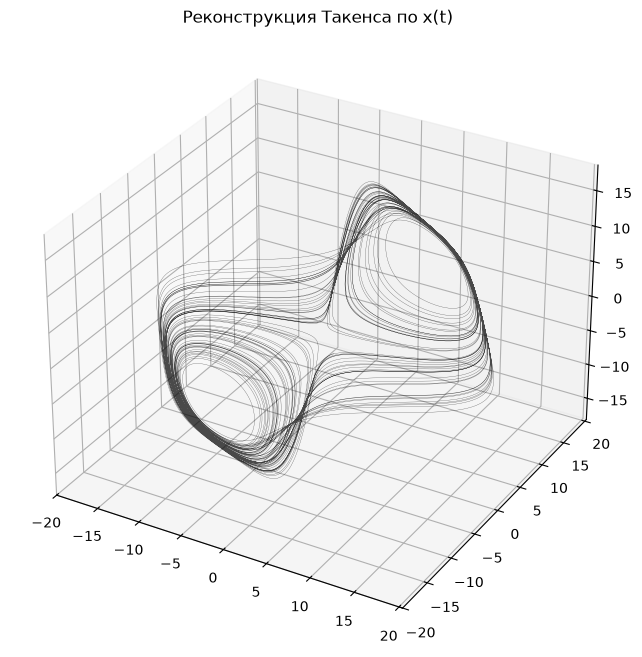

In [22]:
def mutual_information(data, delay, n_bins):
    """
    Calculate the mutual information for a given delay using histograms.
    """
    # Prepare delayed data
    delayed_data = data[delay:]
    original_data = data[:-delay]

    # Compute histograms
    p_x, bin_edges = np.histogram(original_data, bins=n_bins, density=True)
    p_y, _ = np.histogram(delayed_data, bins=bin_edges, density=True)
    p_xy, _, _ = np.histogram2d(original_data, delayed_data, bins=bin_edges, density=True)

    # Calculate mutual information
    mutual_info = 0
    for i in range(n_bins):
        for j in range(n_bins):
            if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mutual_info += p_xy[i, j] * np.log(p_xy[i, j] / (p_x[i] * p_y[j]))

    return mutual_info

def takens_embedding(data, delay, dimension):
    embedding = np.array([data[0:len(data)-delay*dimension]])
    for i in range(1, dimension):
        embedding = np.append(embedding, [data[i*delay:len(data) - delay*(dimension - i)]], axis=0)
    return embedding.transpose()

def calculate_fnn(data, delay, max_emb_dim, R_tol=10):
    fnn_proportions = []
    for m in range(1, max_emb_dim + 1):

        # Compute embeddings in m and m+1
        emb_m = takens_embedding(data, delay, m)
        emb_m_plus_one = takens_embedding(data, delay, m + 1)

        # Compute the nearest neighbors in m
        nbrs = NearestNeighbors(n_neighbors=2).fit(emb_m[:-delay])
        distances, indices = nbrs.kneighbors(emb_m[:-delay])

        n_false_nn = 0
        for i in range(0, len(distances)):

            # Nearest neighbor of i in m and distance from it
            neighbor_index, R_m = indices[i, 1], distances[i, 1]

            # Dinstance in m+1 from the nearest neighbor in m
            R_m_plus_one = np.linalg.norm(emb_m_plus_one[i] - emb_m_plus_one[neighbor_index])

            # fNN formula
            if abs(R_m_plus_one - R_m) / R_m > R_tol:
                n_false_nn += 1

        fnn_proportion = n_false_nn / len(indices)
        fnn_proportions.append(fnn_proportion)

    return fnn_proportions

# Реконструкция Такенса по x(t), выбор tau и m через MI + FNN
max_delay = 80
mi_curve = np.array([mutual_information(x_ts, delay=d, n_bins=60) for d in range(1, max_delay + 1)])

local_min_idx = np.where((mi_curve[1:-1] < mi_curve[:-2]) & (mi_curve[1:-1] < mi_curve[2:]))[0]
if local_min_idx.size > 0:
    tau_opt = int(local_min_idx[0] + 2)
else:
    tau_opt = int(np.argmin(mi_curve) + 1)

plt.figure(figsize=(10, 3.2))
plt.plot(np.arange(1, max_delay + 1), mi_curve, marker="o", ms=2.5)
plt.axvline(tau_opt, color="C3", ls="--", label=f"tau={tau_opt}")
plt.title("Взаимная информация от задержки")
plt.xlabel("задержка tau")
plt.ylabel("MI")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

max_emb_dim = 12
fnn_curve = np.array(calculate_fnn(x_ts, delay=tau_opt, max_emb_dim=max_emb_dim))

fnn_threshold = 0.02
candidates = np.where(fnn_curve < fnn_threshold)[0]
if candidates.size > 0:
    m_opt = int(candidates[0] + 1)
else:
    m_opt = int(np.argmin(fnn_curve) + 1)

plt.figure(figsize=(10, 3.2))
plt.plot(np.arange(1, max_emb_dim + 1), fnn_curve, marker="o", ms=3)
plt.axvline(m_opt, color="C3", ls="--", label=f"m={m_opt}")
plt.title("Доля ложных соседей от размерности вложения")
plt.xlabel("размерность вложения m")
plt.ylabel("доля FNN")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Выбраны параметры: tau={tau_opt}, m={m_opt}")

takens_emb = takens_embedding(x_ts, delay=tau_opt, dimension=max(m_opt, 3))
plot_attractor(takens_emb[:, :3].T, title="Реконструкция Такенса по x(t)", interactive=False)


### Упражнение 5

- Вычислите прогнозы переменной состояния $x(t)$ системы Лоренца, используя вложения задержки Taken и алгоритм регрессии по вашему выбору (регрессия Риджа, случайный лес и т. д.).

,embedding_dim,model,mse,mae
0,3,RandomForest,0.205155,0.281142
1,4,RandomForest,0.259086,0.309306
2,5,RandomForest,0.262676,0.306516
3,3,Ridge,23.859354,4.018399
4,5,Ridge,25.179580,4.091440
5,4,Ridge,25.615568,4.126067


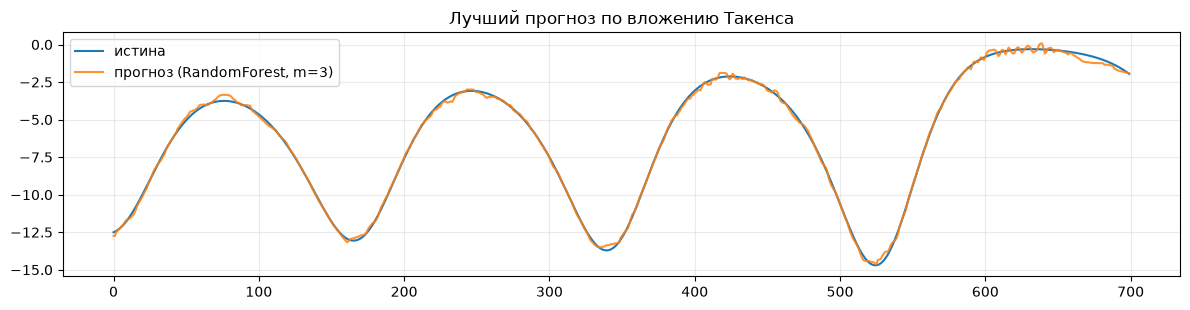

In [28]:
# Прогноз x(t) по вложению Такенса, сравнение Ridge и RandomForest
takens_model_results = []
takens_predictions = {}

for dim in [m_opt, m_opt + 1, m_opt + 2]:
    takens_supervised = takens_embedding(x_ts, delay=tau_opt, dimension=dim + 1)
    X_takens = takens_supervised[:, :-1]
    y_takens = takens_supervised[:, -1]

    split = int(0.9 * len(X_takens))
    X_train_t, X_test_t = X_takens[:split], X_takens[split:]
    y_train_t, y_test_t = y_takens[:split], y_takens[split:]

    ridge_takens = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    ridge_takens.fit(X_train_t, y_train_t)
    y_pred_ridge = ridge_takens.predict(X_test_t)

    rf_takens = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=123,
        n_jobs=-1,
    )
    rf_takens.fit(X_train_t, y_train_t)
    y_pred_rf = rf_takens.predict(X_test_t)

    takens_model_results.extend(
        [
            {
                "embedding_dim": dim,
                "model": "Ridge",
                "mse": mean_squared_error(y_test_t, y_pred_ridge),
                "mae": mean_absolute_error(y_test_t, y_pred_ridge),
            },
            {
                "embedding_dim": dim,
                "model": "RandomForest",
                "mse": mean_squared_error(y_test_t, y_pred_rf),
                "mae": mean_absolute_error(y_test_t, y_pred_rf),
            },
        ]
    )

    takens_predictions[(dim, "Ridge")] = (y_test_t, y_pred_ridge)
    takens_predictions[(dim, "RandomForest")] = (y_test_t, y_pred_rf)

takens_table = pd.DataFrame(takens_model_results).sort_values(["mse", "mae"]).reset_index(drop=True)
display(takens_table.round(6))

best_takens = takens_table.iloc[0]
best_key = (int(best_takens["embedding_dim"]), best_takens["model"])
y_true_takens, y_pred_takens = takens_predictions[best_key]

plt.figure(figsize=(12, 3.2))
plt.plot(y_true_takens[:700], label="истина")
plt.plot(y_pred_takens[:700], label=f"прогноз ({best_key[1]}, m={best_key[0]})", alpha=0.85)
plt.title("Лучший прогноз по вложению Такенса")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Упражнение 6

- Вычислите прогнозы переменной состояния $x(t)$ системы Лоренца с помощью ESN, используя горизонт прогнозирования по вашему выбору.
- Создайте трехмерный график состояний Резервуара, уменьшенный до трех измерений с помощью PCA, и сравните его с реальным аттрактором Лоренца.

,features,model,mse,mae
0,raw_states,RandomForest,0.010447,0.029272
1,raw_states,Ridge,0.029674,0.060124
2,pca_states_3d,RandomForest,0.164243,0.142083
3,pca_states_3d,Ridge,0.587171,0.604710


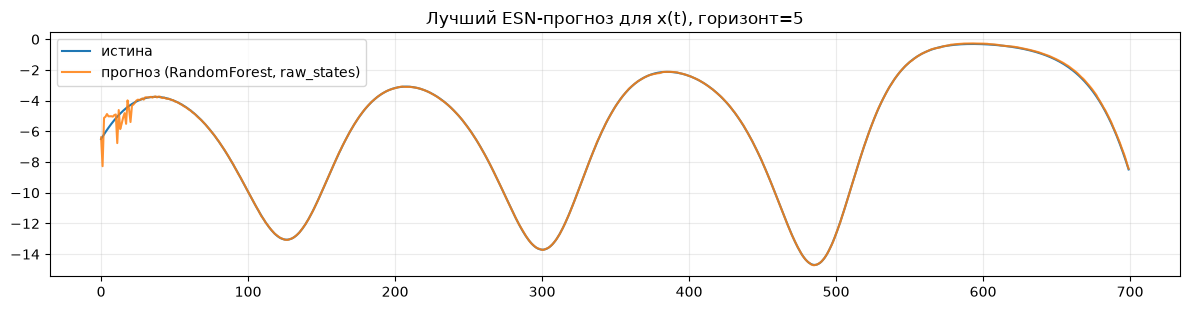

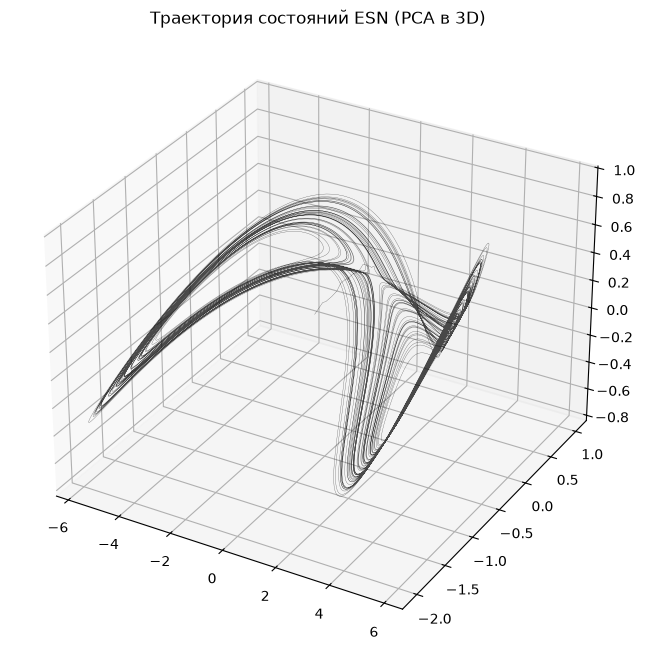

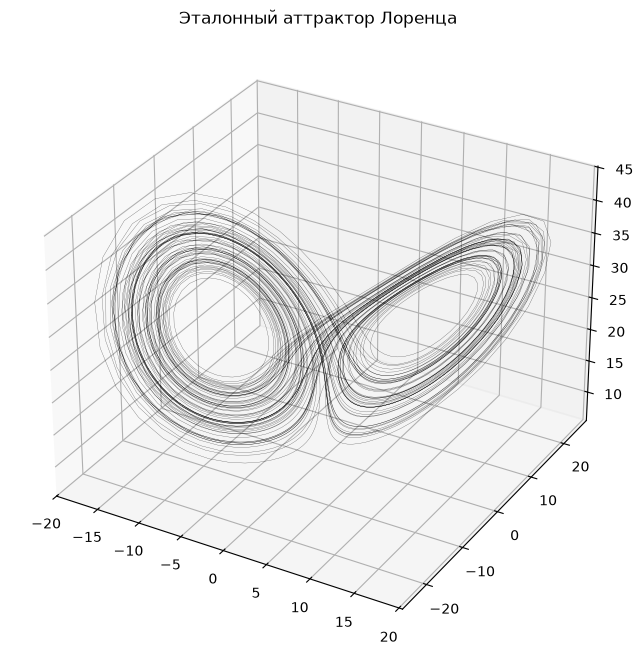

In [ ]:
# Прогноз x(t) через ESN, сравнение readout-моделей и PCA
horizon_esn = 5
Xtr_esn, Ytr_esn, Xte_esn, Yte_esn, scaler_esn = make_forecasting_dataset(
    x_ts[:, None], horizon=horizon_esn, test_percent=0.1
)

n_drop = 10
esn = Reservoir(
    n_internal_units=700,
    spectral_radius=0.99,
    input_scaling=0.1,
    connectivity=0.25,
)

states_tr = esn.get_states(Xtr_esn[None, :, :], n_drop=n_drop, bidir=False)[0]
states_te = esn.get_states(Xte_esn[None, :, :], n_drop=n_drop, bidir=False)[0]
y_train_esn = Ytr_esn[n_drop:, 0]
y_true_esn = Yte_esn[n_drop:, 0]

pca_states = PCA(n_components=3)
states_tr_pca = pca_states.fit_transform(states_tr)
states_te_pca = pca_states.transform(states_te)

esn_results = []
esn_preds = {}

for feature_name, Xtr_feat, Xte_feat in [
    ("raw_states", states_tr, states_te),
    ("pca_states_3d", states_tr_pca, states_te_pca),
]:
    ridge_readout = Ridge(alpha=1.0)
    ridge_readout.fit(Xtr_feat, y_train_esn)
    y_pred_ridge_scaled = ridge_readout.predict(Xte_feat)
    y_pred_ridge = scaler_esn.inverse_transform(y_pred_ridge_scaled.reshape(-1, 1)).ravel()

    rf_readout = RandomForestRegressor(
        n_estimators=350,
        max_depth=14,
        random_state=123,
        n_jobs=-1
    )
    rf_readout.fit(Xtr_feat, y_train_esn)
    y_pred_rf_scaled = rf_readout.predict(Xte_feat)
    y_pred_rf = scaler_esn.inverse_transform(y_pred_rf_scaled.reshape(-1, 1)).ravel()

    for model_name, y_pred in [("Ridge", y_pred_ridge), ("RandomForest", y_pred_rf)]:
        esn_results.append(
            {
                "features": feature_name,
                "model": model_name,
                "mse": mean_squared_error(y_true_esn, y_pred),
                "mae": mean_absolute_error(y_true_esn, y_pred),
            }
        )
        esn_preds[(feature_name, model_name)] = y_pred

esn_table = pd.DataFrame(esn_results).sort_values(["mse", "mae"]).reset_index(drop=True)
display(esn_table.round(6))

best_esn = esn_table.iloc[0]
best_esn_key = (best_esn["features"], best_esn["model"])
y_pred_best_esn = esn_preds[best_esn_key]

plt.figure(figsize=(12, 3.2))
plt.plot(y_true_esn[:700], label="истина")
plt.plot(y_pred_best_esn[:700], label=f"прогноз ({best_esn_key[1]}, {best_esn_key[0]})", alpha=0.85)
plt.title(f"Лучший ESN-прогноз для x(t), горизонт={horizon_esn}")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plot_attractor(states_tr_pca.T, title="Траектория состояний ESN (PCA в 3D)", interactive=False)
plot_attractor(lor_traj[::5, :3].T, title="Эталонный аттрактор Лоренца", interactive=False)
